In [2]:
import numpy as np

# Define the environment (simple grid world)
class GridWorld:
    def __init__(self):
        self.states = [0, 1, 2, 3, 4]  # States
        self.terminal_states = [0, 4]  # Terminal states
        self.actions = ['left', 'right']  # Possible actions
        self.rewards = {0: 0, 1: 0, 2: 0, 3: 0, 4: 1}  # Rewards for each state
        self.state = 2  # Start state

    def reset(self):
        self.state = 2  # Reset to start state
        return self.state

    def step(self, action):
        if self.state in self.terminal_states:
            return self.state, self.rewards[self.state], True  # Terminal state

        if action == 'left':
            next_state = self.state - 1
        elif action == 'right':
            next_state = self.state + 1

        # Ensure the next state is within bounds
        next_state = max(0, min(4, next_state))

        reward = self.rewards[next_state]
        done = next_state in self.terminal_states
        self.state = next_state

        return next_state, reward, done

# TD(0) Learning Algorithm
def td_learning(env, episodes=1000, alpha=0.1, gamma=0.99):
    # Initialize value function
    V = np.zeros(len(env.states))

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            # Choose a random action
            action = np.random.choice(env.actions)

            # Take the action and observe the next state and reward
            next_state, reward, done = env.step(action)

            # TD(0) update
            td_target = reward + gamma * V[next_state]
            td_error = td_target - V[state]
            V[state] += alpha * td_error

            # Move to the next state
            state = next_state

    return V

# Run the TD(0) algorithm
env = GridWorld()
value_function = td_learning(env, episodes=1000)

# Print the learned value function
print("Learned Value Function:")
for state, value in enumerate(value_function):
    print(f"State {state}: {value:.4f}")

Learned Value Function:
State 0: 0.0000
State 1: 0.1738
State 2: 0.3626
State 3: 0.7535
State 4: 0.0000


Learned Value Function:
State 0: 0.0000
State 1: 0.2874
State 2: 0.6113
State 3: 0.7941
State 4: 0.0000


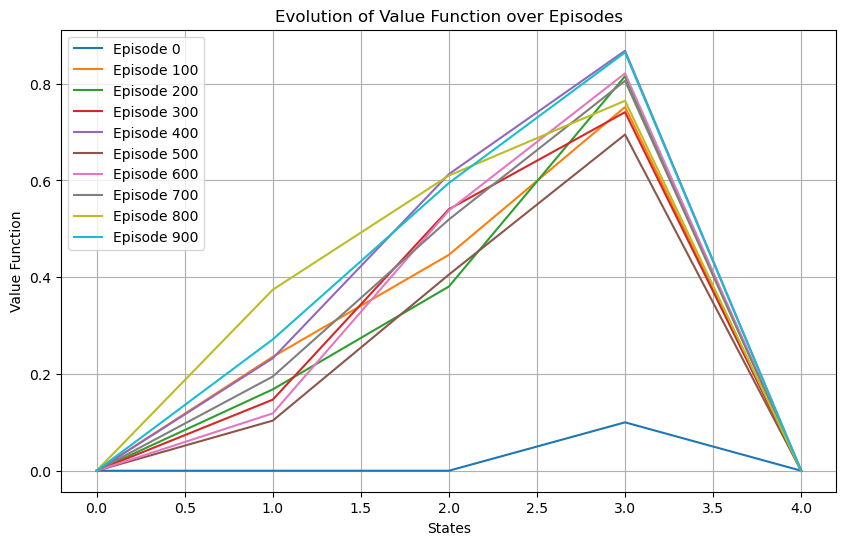

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the environment (simple grid world)
class GridWorld:
    def __init__(self):
        self.states = [0, 1, 2, 3, 4]  # States
        self.terminal_states = [0, 4]  # Terminal states
        self.actions = ['left', 'right']  # Possible actions
        self.rewards = {0: 0, 1: 0, 2: 0, 3: 0, 4: 1}  # Rewards for each state
        self.state = 2  # Start state

    def reset(self):
        self.state = 2  # Reset to start state
        return self.state

    def step(self, action):
        if self.state in self.terminal_states:
            return self.state, self.rewards[self.state], True  # Terminal state

        if action == 'left':
            next_state = self.state - 1
        elif action == 'right':
            next_state = self.state + 1

        # Ensure the next state is within bounds
        next_state = max(0, min(4, next_state))

        reward = self.rewards[next_state]
        done = next_state in self.terminal_states
        self.state = next_state

        return next_state, reward, done

# TD(0) Learning Algorithm with Visualization
def td_learning(env, episodes=1000, alpha=0.1, gamma=0.99, plot_interval=100):
    # Initialize value function
    V = np.zeros(len(env.states))

    # List to store value functions for visualization
    value_history = []

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            # Choose a random action
            action = np.random.choice(env.actions)

            # Take the action and observe the next state and reward
            next_state, reward, done = env.step(action)

            # TD(0) update
            td_target = reward + gamma * V[next_state]
            td_error = td_target - V[state]
            V[state] += alpha * td_error

            # Move to the next state
            state = next_state

        # Store the value function at intervals for visualization
        if episode % plot_interval == 0:
            value_history.append(V.copy())

    return V, value_history

# Run the TD(0) algorithm
env = GridWorld()
value_function, value_history = td_learning(env, episodes=1000, plot_interval=100)

# Print the learned value function
print("Learned Value Function:")
for state, value in enumerate(value_function):
    print(f"State {state}: {value:.4f}")

# Plot the evolution of the value function
plt.figure(figsize=(10, 6))
for i, V in enumerate(value_history):
    plt.plot(V, label=f'Episode {i * 100}')
plt.xlabel('States')
plt.ylabel('Value Function')
plt.title('Evolution of Value Function over Episodes')
plt.legend()
plt.grid()
plt.show()

Learned Value Function:
State 0: 0.0000
State 1: 0.1399
State 2: 0.3849
State 3: 0.7317
State 4: 0.0000


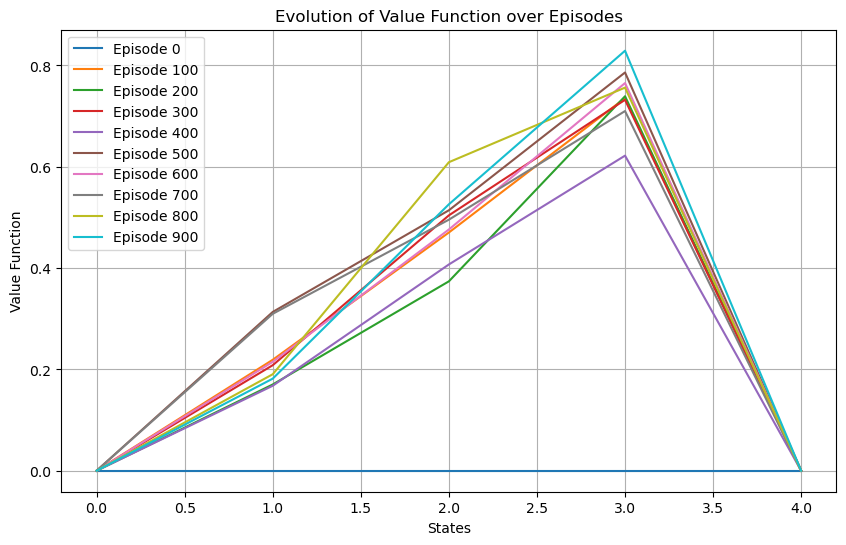

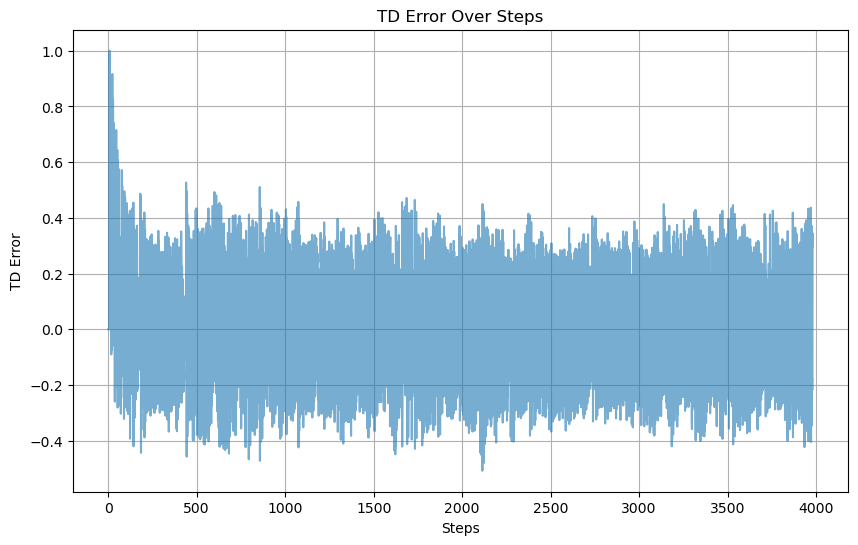

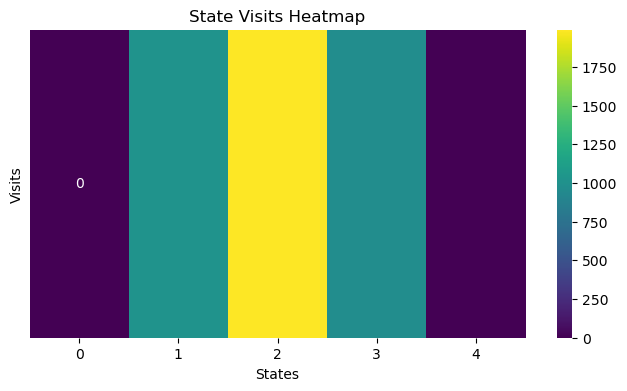

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#used for defining the environment.
class GridWorld:
    def __init__(self):
        self.states = [0, 1, 2, 3, 4]  
        self.terminal_states = [0, 4]  
        self.actions = ['left', 'right']  
        self.rewards = {0: 0, 1: 0, 2: 0, 3: 0, 4: 1} 
        self.state = 2  

    def reset(self):
        self.state = 2  
        return self.state

    def step(self, action):
        if self.state in self.terminal_states:
            return self.state, self.rewards[self.state], True  

        if action == 'left':
            next_state = self.state - 1
        elif action == 'right':
            next_state = self.state + 1

        
        next_state = max(0, min(4, next_state))

        reward = self.rewards[next_state]
        done = next_state in self.terminal_states
        self.state = next_state

        return next_state, reward, done


def td_learning(env, episodes=1000, alpha=0.1, gamma=0.99, plot_interval=100):
   
    V = np.zeros(len(env.states))

    
    value_history = []  
    td_errors = []      
    state_visits = np.zeros(len(env.states))

    for episode in range(episodes):
        state = env.reset()
        done = False

        while not done:
            
            action = np.random.choice(env.actions)

        
            next_state, reward, done = env.step(action)

           
            td_target = reward + gamma * V[next_state]
            td_error = td_target - V[state]
            V[state] += alpha * td_error

          
            td_errors.append(td_error)
            state_visits[state] += 1

           
            state = next_state

       
        if episode % plot_interval == 0:
            value_history.append(V.copy())

    return V, value_history, td_errors, state_visits


env = GridWorld()
value_function, value_history, td_errors, state_visits = td_learning(env, episodes=1000, plot_interval=100)


print("Learned Value Function:")
for state, value in enumerate(value_function):
    print(f"State {state}: {value:.4f}")

#for visulization 1 
plt.figure(figsize=(10, 6))
for i, V in enumerate(value_history):
    plt.plot(V, label=f'Episode {i * 100}')
plt.xlabel('States')
plt.ylabel('Value Function')
plt.title('Evolution of Value Function over Episodes')
plt.legend()
plt.grid()
plt.show()

# for Visualization 2: TD error 
plt.figure(figsize=(10, 6))
plt.plot(td_errors, alpha=0.6)
plt.xlabel('Steps')
plt.ylabel('TD Error')
plt.title('TD Error Over Steps')
plt.grid()
plt.show()

#for visualization of heat map 
plt.figure(figsize=(8, 4))
sns.heatmap([state_visits], annot=True, cmap='viridis', xticklabels=env.states, yticklabels=False)
plt.xlabel('States')
plt.ylabel('Visits')
plt.title('State Visits Heatmap')
plt.show()